# Lab Day 1 — Notebook (PSEUDO-CODE)

> **Đây là khung pseudo-code.** Mọi ô có `# TODO` là phần bạn phải tự viết. Hãy giữ cấu trúc mục (Part 0–4) và
> viết dự đoán/nhận xét bằng chữ của bạn. Đọc `README.md`, `GUIDE.md`, `RUBRIC.md` trước.
>
> **Quy trình làm bài**
> 1. `git pull` repo, tạo thư mục nộp: copy cả thư mục `code/` vào `submission_<MSSV>/code/`.
> 2. Mở `submission_<MSSV>/code/lab.ipynb` và làm việc **tại đó** (nên `REPO_ROOT = "../.."` đúng và ảnh/kết quả ghi vào `submission_<MSSV>/figures`, `results`).
> 3. Ở Colab: chạy ô clone repo bên dưới, rồi làm tương tự (đặt `REPO_ROOT` cho đúng).
> 4. Cuối cùng: `Restart & Run All` phải chạy hết không lỗi và giữ nguyên output.

In [1]:
# ===== Cấu hình đường dẫn và môi trường =====
import os, sys, json, time, subprocess
import numpy as np, torch

REPO_ROOT = "../.."     # thư mục gốc repo (chứa data/ và scripts/), tính từ submission_<MSSV>/code/
OUT_DIR   = ".."        # nơi ghi figures/, results/, experiments.xlsx, predictions_eval.csv (= submission_<MSSV>/)
# Colab: nếu chưa có repo, bỏ comment 2 dòng dưới, rồi đặt REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"
# !git clone https://github.com/VinUni-AI20k/K4-Track4-Day1-Neuralnetwork.git
# REPO_ROOT = "/content/K4-Track4-Day1-Neuralnetwork"

# TODO: chọn device ("cuda" nếu có GPU, ngược lại "cpu"; trên Mac có thể "mps"); in torch.__version__ và tên GPU
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("PyTorch:", torch.__version__, "Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
# TODO: os.makedirs cho f"{OUT_DIR}/figures" và f"{OUT_DIR}/results"

from data import prepare_data, iterate_batches
from model import MLP, EXPECTED_PARAMS, count_params, init_weights, activation_stats
from optimizer import build_optimizer, clip_gradients
from train import DEFAULT_CFG, set_seed, evaluate, predict, run_experiment, final_eval
from plots import plot_run, plot_compare
from results_table import save_result, load_results, to_row, write_xlsx

# Cùng số thread cho các phép đo CPU.
if device == "cpu":
    torch.set_num_threads(1)
os.makedirs(f"{OUT_DIR}/figures", exist_ok=True)
os.makedirs(f"{OUT_DIR}/results", exist_ok=True)


PyTorch: 2.14.1+cpu Device: cpu


## Part 0 — Dữ liệu
Chia sẵn bằng metadata: chạy `scripts/split_data.py` từ thư mục gốc repo (tạo `data/processed/train.npz`, `eval.npz`).
Sau đó tách validation từ train, chuẩn hoá bằng thống kê của train, đưa lên device.


Gi? l? cu?i d? s? m?u nh? h?n batch size: kh?ng b? m?u, kh?ng th?m m?u. V?i batch size 512, l? cu?i c? 135 m?u. Mean/std ch? t?nh t? train sau khi t?ch validation, r?i d?ng chung cho val v? eval.


In [2]:
from pathlib import Path
processed_dir = Path(REPO_ROOT) / "data" / "processed"
if not all((processed_dir / name).exists() for name in ("train.npz", "eval.npz")):
    subprocess.run([sys.executable, "scripts/split_data.py"], cwd=REPO_ROOT, check=True)
data = prepare_data(device, val_fraction=0.2, seed=42, processed_dir=str(processed_dir))

numeric = data["X_tr"][:, :10].to(torch.float64)
means = numeric.mean(dim=0)
stds = numeric.std(dim=0, correction=0)
print("Mean of 10 numeric columns:", means.cpu().numpy())
print("Std of 10 numeric columns:", stds.cpu().numpy())
assert torch.allclose(means, torch.zeros_like(means), atol=1e-5, rtol=0)
assert torch.allclose(stds, torch.ones_like(stds), atol=1e-5, rtol=0)

batch_size = 512
generator = torch.Generator(device=device).manual_seed(42)
n_seen = n_batches = last_batch_size = 0
for xb, yb in iterate_batches(data["X_tr"], data["y_tr"], batch_size, generator=generator):
    assert xb.shape == (len(yb), 54)
    n_seen += len(yb)
    n_batches += 1
    last_batch_size = len(yb)
assert n_seen == len(data["X_tr"])
assert last_batch_size == (n_seen - 1) % batch_size + 1
print(f"Batches: {n_batches}; samples: {n_seen}; last batch: {last_batch_size}")


X_tr: (371847, 54), y_tr: (371847,)
X_val: (92962, 54), y_val: (92962,)
X_eval: (116203, 54), y_eval: (116203,)
Majority class (from train): 1; val accuracy: 0.487597
Mean of 10 numeric columns: [-6.73883753e-11 -1.46488192e-10 -3.42966406e-09  3.00766271e-10
 -1.53744727e-09 -1.02212679e-10 -1.56614732e-09 -1.91377376e-09
 -1.41332503e-09  6.88944764e-10]
Std of 10 numeric columns: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Batches: 727; samples: 371847; last batch: 135


## Part 1 — Model và kiểm tra "sức khoẻ" ban đầu
Quy định: `M-base` = `54 → 256 → 128 → 7`, **47 879 tham số**, logits `(B, 7)`, không softmax trong model.

In [3]:
# TODO 1: Tạo model và kiểm tra số tham số (các giá trị model sẽ học).
# Cố định cách sinh số ngẫu nhiên để dễ chạy lại và so sánh kết quả.
torch.manual_seed(42)
# Hai lớp ẩn có 256 và 128 nơ-ron; không tắt ngẫu nhiên nơ-ron (dropout=0).
# He đặt trọng số ban đầu phù hợp với ReLU; .to(device) đưa model lên CPU/GPU đã chọn.
model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
# assert dừng chương trình nếu số tham số không đúng 47 879.
assert count_params(model) == EXPECTED_PARAMS[(256, 128)] == 47_879
print("Parameters:", count_params(model))

# TODO 2: Cho dữ liệu thử đi qua từng lớp và kiểm trppa kích thước.
# Chuyển sang chế độ kiểm tra; các lớp Dropout (nếu có) sẽ không tắt nơ-ron.
model.eval()
# Tạo 8 mẫu ngẫu nhiên, mỗi mẫu có 54 đặc trưng; dùng cùng thiết bị với model.
x = torch.randn(8, 54, device=device)
# Linear đổi số đặc trưng; ReLU chỉ đổi giá trị nên giữ nguyên kích thước.
expected_shapes = [(8, 256), (8, 256), (8, 128), (8, 128), (8, 7)]
print("Input:", tuple(x.shape))
# Không cần tính gradient (mức ảnh hưởng của tham số tới loss) khi chỉ kiểm tra đầu ra.
with torch.no_grad():
    # h giữ đầu ra hiện tại và được truyền tiếp cho lớp sau.
    h = x
    # zip ghép mỗi lớp với kích thước mong đợi; enumerate thêm số thứ tự lớp.
    for i, (layer, expected) in enumerate(zip(model.net, expected_shapes)):
        # Đưa dữ liệu qua đúng một lớp.
        h = layer(h)
        print(f"Layer {i}: {layer} -> {tuple(h.shape)}")
        assert tuple(h.shape) == expected
    # logits là 7 điểm số cho mỗi mẫu, chưa chuyển thành xác suất.
    # Chạy cả model để đối chiếu với cách chạy từng lớp ở trên.
    logits = model(x)
assert len(model.net) == len(expected_shapes)
# 8 mẫu đầu vào phải cho 8 hàng đầu ra, mỗi hàng gồm 7 điểm số.
assert logits.shape == (8, 7)
# Hai cách chạy phải cho kết quả gần bằng nhau (cho phép sai số rất nhỏ).
assert torch.allclose(h, logits)


Parameters: 47879
Input: (8, 54)
Layer 0: Linear(in_features=54, out_features=256, bias=True) -> (8, 256)
Layer 1: ReLU() -> (8, 256)
Layer 2: Linear(in_features=256, out_features=128, bias=True) -> (8, 128)
Layer 3: ReLU() -> (8, 128)
Layer 4: Linear(in_features=128, out_features=7, bias=True) -> (8, 7)


In [4]:
# TODO 3: Đo loss (mức sai của dự đoán) trên val trước khi cập nhật trọng số.
import math
import torch.nn.functional as F

# Dùng chế độ kiểm tra để đo loss ổn định, không bật Dropout.
model.eval()
# Cộng loss của tất cả mẫu rồi chia số mẫu để lấy trung bình toàn bộ val.
val_loss_sum = 0.0
# Chỉ đo kết quả, không cần lưu thông tin để tính gradient.
with torch.no_grad():
    # Chia val thành các lô tối đa 8192 mẫu để giảm bộ nhớ cần dùng.
    # xb là đặc trưng của lô, yb là nhãn đúng; không cần xáo trộn khi đo loss.
    for xb, yb in iterate_batches(data["X_val"], data["y_val"], 8192, shuffle=False):
        # cross_entropy nhận điểm số thô và nhãn đúng; không thêm softmax trước nó.
        # reduction="sum" cộng loss trong lô; .item() lấy số Python từ tensor.
        val_loss_sum += F.cross_entropy(model(xb), yb, reduction="sum").item()
# Chia tổng loss cho tổng số mẫu; lô cuối nhỏ hơn vẫn được tính đúng.
step0_loss = val_loss_sum / len(data["y_val"])
# log là ln (logarit tự nhiên); ln(7) là loss khi mỗi lớp có xác suất 1/7.
uniform_loss = math.log(7)
print(f"Step-0 val loss: {step0_loss:.6f}")
print(f"ln(7): {uniform_loss:.6f}; difference: {step0_loss - uniform_loss:+.6f}")
# Kiểm tra loss là số hữu hạn, không phải NaN (không xác định) hay vô cực.
assert math.isfinite(step0_loss)
# He tạo các điểm số ngẫu nhiên khác nhau, nên loss ban đầu có thể lệch ln(7).


Step-0 val loss: 2.377572
ln(7): 1.945910; difference: +0.431662


In [5]:
# TODO 4: Cho model học đi học lại 20 mẫu train để kiểm tra có học được không.
# Dùng model riêng để model ban đầu vẫn chưa được cập nhật trọng số.
import matplotlib.pyplot as plt
from pathlib import Path

# Cố định số ngẫu nhiên cho lần thử học thuộc này.
torch.manual_seed(42)
# Tắt Dropout để model dễ học thuộc toàn bộ 20 mẫu.
small_model = MLP(hidden=(256, 128), dropout=0.0, init="he").to(device)
# Adam là cách cập nhật trọng số; lr=0.01 điều chỉnh mức thay đổi mỗi bước.
# weight_decay=0 tắt phần phạt trọng số lớn để thử học thuộc dễ hơn.
optimizer = torch.optim.Adam(small_model.parameters(), lr=0.01, weight_decay=0.0)
# Xáo trộn chỉ số các mẫu train rồi lấy 20 chỉ số đầu; không lấy mẫu từ val/eval.
indices = torch.randperm(len(data["X_tr"]), device=device)[:20]
# Lấy đặc trưng và nhãn theo cùng chỉ số để không ghép nhầm mẫu với nhãn.
x_small, y_small = data["X_tr"][indices], data["y_tr"][indices]
assert len(y_small) == 20
# Bật chế độ huấn luyện; Dropout vẫn tắt vì đã đặt bằng 0.
small_model.train()
with torch.no_grad():
    # Lưu loss trước lần cập nhật đầu tiên làm mốc so sánh.
    small_losses = [F.cross_entropy(small_model(x_small), y_small).item()]
# Mỗi bước đều học lại đúng 20 mẫu này; mục tiêu là học thuộc chúng.
for step in range(300):
    # Xoá gradient cũ để không cộng dồn từ bước trước.
    optimizer.zero_grad(set_to_none=True)
    # Dự đoán 20 mẫu và tính mức sai so với nhãn đúng.
    loss = F.cross_entropy(small_model(x_small), y_small)
    assert torch.isfinite(loss).item(), f"Non-finite loss at step {step}"
    # Tính gradient: mỗi tham số ảnh hưởng đến loss như thế nào.
    loss.backward()
    # Dùng gradient vừa tính để cập nhật trọng số nhằm giảm loss.
    optimizer.step()
    with torch.no_grad():
        # Đo lại loss SAU cập nhật và lưu để vẽ đường cong.
        small_losses.append(F.cross_entropy(small_model(x_small), y_small).item())

# Kết thúc học, chuyển sang chế độ kiểm tra kết quả.
small_model.eval()
with torch.no_grad():
    small_logits = small_model(x_small)
    final_small_loss = F.cross_entropy(small_logits, y_small).item()
    # argmax chọn lớp có điểm cao nhất; so với nhãn đúng rồi lấy tỉ lệ dự đoán đúng.
    small_accuracy = (small_logits.argmax(dim=1) == y_small).float().mean().item()
print(f"20 samples: loss {small_losses[0]:.6f} -> {final_small_loss:.8f}")
print(f"20 samples: accuracy = {small_accuracy:.1%}")
# Quy ước "gần 0" ở phép thử này là loss < 0.01.
assert final_small_loss < 0.01, "The model has not memorized the 20 samples yet"
# Yêu cầu dự đoán đúng cả 20 mẫu, tức accuracy = 100%.
assert small_accuracy == 1.0

# Tạo biểu đồ: trục ngang là số bước cập nhật, trục dọc là loss.
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(small_losses)), small_losses)
ax.set(xlabel="Update step", ylabel="Cross-entropy loss", title="Overfit 20 training samples (dropout=0)")
ax.grid(alpha=0.3)
fig.tight_layout()
# Lưu ảnh vào thư mục figures của bài nộp.
figure_path = Path(OUT_DIR) / "figures" / "part1_overfit20.png"
# Tạo thư mục nếu chưa có; exist_ok=True cho phép thư mục đã tồn tại.
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, dpi=150)
# Hiển thị biểu đồ ngay dưới ô notebook.
plt.show()


20 samples: loss 2.166669 -> 0.00000725
20 samples: accuracy = 100.0%


C:\Users\vieta\AppData\Local\Temp\ipykernel_6836\2660231206.py:64: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [6]:
# TODO 5: Kiểm tra gradient trên model ban đầu, chưa cập nhật trọng số.
# Chuẩn gradient là một số đo độ lớn tổng thể của gradient trong một nhóm tham số.
model.train()
# Xoá gradient để phép kiểm tra chỉ phản ánh lần backward này.
model.zero_grad(set_to_none=True)
# Dùng 20 mẫu có nhãn thật để tính loss trên model ban đầu.
grad_loss = F.cross_entropy(model(x_small), y_small)
# Tính gradient và lưu vào thuộc tính .grad của từng tham số.
grad_loss.backward()
grad_norms = {}
# Duyệt từng nhóm trọng số (weight) và giá trị cộng thêm (bias) kèm tên.
for name, parameter in model.named_parameters():
    # None nghĩa là tham số không nhận được gradient trong phép tính này.
    assert parameter.grad is not None, f"{name}: missing gradient"
    # .norm() gộp độ lớn các phần tử gradient thành một số; .item() lấy số Python.
    grad_norm = parameter.grad.norm().item()
    print(f"{name}: grad norm = {grad_norm:.8f}")
    # Mỗi nhóm phải có gradient hữu hạn và có độ lớn > 0.
    # Không yêu cầu từng phần tử gradient đều khác 0.
    assert math.isfinite(grad_norm) and grad_norm > 0, f"{name}: invalid gradient"
    # Lưu số đo theo tên tham số để có thể xem lại.
    grad_norms[name] = grad_norm
# Xoá gradient để phép kiểm tra chỉ phản ánh lần backward này.
model.zero_grad(set_to_none=True)
# Không gọi optimizer.step(): model ban đầu vẫn chưa được cập nhật trọng số.
model.eval()


net.0.weight: grad norm = 0.95519239
net.0.bias: grad norm = 0.42337298
net.2.weight: grad norm = 2.52853632
net.2.bias: grad norm = 0.47124234
net.4.weight: grad norm = 1.98230147
net.4.bias: grad norm = 0.54287136


MLP(
  (net): Sequential(
    (0): Linear(in_features=54, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)

**Nhận xét Part 1:**
> Kiểm tra shape: đúng **47 879 tham số**

> Shape đi qua các lớp đúng: (8, 54) → (8, 256) → (8, 256) → (8, 128) → (8, 128) → (8, 7)`.

> Loss bước 0 trên tập val là **2.377572**, cao hơn `ln(7) = 1.945910` khoảng **0.431662**. Chênh khá nhiều, có thể là do he_init

> Train thử với 20 samples, có overfit, nên không lỗi code

> Gradient 1 lần, tất cả gradient của các bộ weight đều khác 0, nên mạng không đứt


## Part 2 — Pipeline và baseline
`run_experiment(cfg, data)` nhận một dict cấu hình và trả về lịch sử + tóm tắt. Baseline: SGD+momentum 0.9, CE, He init, batch 512, 20 epoch.

### 2a. Chọn learning rate bằng validation
Thử `lr = 0.01, 0.03, 0.1` với cùng seed 1 và 20 epoch (20 lượt học qua tập train).
Giữ nguyên các thành phần còn lại của baseline. Mỗi lần chạy chọn epoch có **val loss thấp nhất**;
sau đó chọn lr có **val macro-F1 cao nhất tại epoch đó**. Macro-F1 là trung bình F1 của 7 lớp,
giúp các lớp ít mẫu cũng được tính ngang với lớp nhiều mẫu. Không dùng tập eval để chọn.

In [7]:
from pathlib import Path
import pandas as pd

results_dir = Path(OUT_DIR) / "results"
figures_dir = Path(OUT_DIR) / "figures"
results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

lr_candidates = [0.01, 0.03, 0.1]
tuning_seed = 1
lr_results = []
lr_rows = []
for lr in lr_candidates:
    exp_id = f"base-lr{lr:g}-s{tuning_seed}"
    trial_cfg = {
        **DEFAULT_CFG, "lr": lr, "seed": tuning_seed,
        "exp_id": exp_id, "group": "baseline_lr",
        "description": "Select baseline learning rate using validation only",
    }
    print(f"Running {exp_id}: {trial_cfg['epochs']} epochs", flush=True)
    result = run_experiment(trial_cfg, data)
    save_result(result, str(results_dir))
    plot_run(result, str(figures_dir / f"{exp_id}.png"))
    lr_results.append(result)
    summary = result["summary"]
    lr_rows.append({
        "exp_id": exp_id, "lr": lr,
        "best_epoch": summary["best_epoch"],
        "best_val_loss": summary["best_val_loss"],
        "val_acc": summary["val_acc"],
        "val_macro_f1": summary["val_macro_f1"],
        "diverged": summary["diverged"],
    })
    print(lr_rows[-1], flush=True)

lr_table = pd.DataFrame(lr_rows)
print("\nLearning rate -> validation metrics:")
print(lr_table.to_string(index=False))
lr_table.to_csv(Path(OUT_DIR) / "part2_lr_search.csv", index=False)

# Loại lần chạy có NaN/inf (số không xác định/vô cực) hoặc chưa học được epoch nào.
valid_trials = [r for r in lr_results if (
    not r["summary"]["diverged"] and r["summary"]["best_epoch"] > 0
    and np.isfinite(r["summary"]["val_macro_f1"])
)]
if not valid_trials:
    raise RuntimeError("No valid learning-rate trial; inspect saved losses and gradient norms")
# Nếu F1 bằng nhau, ưu tiên val loss thấp hơn, rồi lr nhỏ hơn.
selected_trial = max(valid_trials, key=lambda r: (
    r["summary"]["val_macro_f1"],
    -r["summary"]["best_val_loss"], -r["cfg"]["lr"],
))
chosen_lr = selected_trial["cfg"]["lr"]
cfg = {**DEFAULT_CFG, "lr": chosen_lr}
print(f"Selected baseline lr = {chosen_lr:g} (validation only)")

Running base-lr0.01-s1: 20 epochs


{'exp_id': 'base-lr0.01-s1', 'lr': 0.01, 'best_epoch': 19, 'best_val_loss': 0.3174828630940095, 'val_acc': 0.8713022525332932, 'val_macro_f1': 0.7668548342067013, 'diverged': False}


Running base-lr0.03-s1: 20 epochs


{'exp_id': 'base-lr0.03-s1', 'lr': 0.03, 'best_epoch': 20, 'best_val_loss': 0.26113492675539635, 'val_acc': 0.894107269637056, 'val_macro_f1': 0.822192110385046, 'diverged': False}


Running base-lr0.1-s1: 20 epochs


{'exp_id': 'base-lr0.1-s1', 'lr': 0.1, 'best_epoch': 20, 'best_val_loss': 0.23633452186675571, 'val_acc': 0.9059400615305179, 'val_macro_f1': 0.8569841017203065, 'diverged': False}



Learning rate -> validation metrics:
        exp_id   lr  best_epoch  best_val_loss  val_acc  val_macro_f1  diverged
base-lr0.01-s1 0.01          19       0.317483 0.871302      0.766855     False
base-lr0.03-s1 0.03          20       0.261135 0.894107      0.822192     False
 base-lr0.1-s1 0.10          20       0.236335 0.905940      0.856984     False
Selected baseline lr = 0.1 (validation only)


### 2b. Chạy baseline với ba seed
Dùng lr đã chọn và các seed `1, 2, 3`; giữ nguyên cách chia train/val ở Part 0.
Seed chỉ thay đổi trọng số ban đầu và thứ tự các lô học.

In [8]:
baseline_seeds = [1, 2, 3]
baseline_results = []
for seed in baseline_seeds:
    exp_id = f"base-s{seed}"
    seed_cfg = {**cfg, "seed": seed, "exp_id": exp_id}
    print(f"Running {exp_id}: lr={chosen_lr:g}, {seed_cfg['epochs']} epochs", flush=True)
    result = run_experiment(seed_cfg, data)
    save_result(result, str(results_dir))
    plot_run(result, str(figures_dir / f"{exp_id}.png"))
    baseline_results.append(result)
    print(result["summary"], flush=True)

# Không bỏ âm thầm seed lỗi vì có thể làm số đo nhiễu thấp đi.
if any(r["summary"]["diverged"] or r["summary"]["best_epoch"] == 0
       for r in baseline_results):
    raise RuntimeError("A baseline seed failed; inspect its logs before estimating seed noise")

baseline_table = pd.DataFrame([
    {"exp_id": r["cfg"]["exp_id"], "seed": r["cfg"]["seed"], **r["summary"]}
    for r in baseline_results
])
print("\nBaseline results (metrics at the epoch with lowest val loss):")
print(baseline_table.to_string(index=False))
baseline_table.to_csv(Path(OUT_DIR) / "part2_baseline_seeds.csv", index=False)

# Giữ seed 1 làm model tham chiếu cho bước đánh giá cuối; không chọn seed tốt nhất.
baseline_result = baseline_results[0]

Running base-s1: lr=0.1, 20 epochs


{'step0_loss': 2.2690618094036408, 'best_val_loss': 0.23633452186675571, 'best_epoch': 20, 'final_train_loss': 0.21322071107334006, 'final_val_loss': 0.23633452186675571, 'val_acc': 0.9059400615305179, 'val_macro_f1': 0.8569841017203065, 'time_per_epoch_s': 2.3515205050003716, 'peak_mem_MB': None, 'diverged': False, 'divergence_reason': '', 'optimizer_steps': 14540, 'grad_norm_max': 2.8710765838623047, 'clip_fraction': 0.0, 'cpu_peak_rss_MB': 645.21875, 'step0_activation_std': [0.6662027835845947, 0.6463822722434998, 0.5932615995407104], 'activation_measurement': 'after each Linear, including logits; std(correction=0); first 512 val samples; FP32', 'step0_grad_norm_by_parameter': {'net.0.weight': 0.5051687955856323, 'net.0.bias': 0.34434694051742554, 'net.2.weight': 1.974709391593933, 'net.2.bias': 0.43847426772117615, 'net.4.weight': 1.914792776107788, 'net.4.bias': 0.558370053768158}, 'device': 'cpu', 'torch_version': '2.14.1+cpu', 'cpu_threads': 1, 'n_train': 371847, 'n_val': 92962}

Running base-s2: lr=0.1, 20 epochs


{'step0_loss': 1.9781567018815485, 'best_val_loss': 0.21824840239451, 'best_epoch': 20, 'final_train_loss': 0.1949618845447838, 'final_val_loss': 0.21824840239451, 'val_acc': 0.9123835545706848, 'val_macro_f1': 0.8613678403931262, 'time_per_epoch_s': 5.336109170009149, 'peak_mem_MB': None, 'diverged': False, 'divergence_reason': '', 'optimizer_steps': 14540, 'grad_norm_max': 2.3896379470825195, 'clip_fraction': 0.0, 'cpu_peak_rss_MB': 653.046875, 'step0_activation_std': [0.6790912747383118, 0.6944661736488342, 0.5449286699295044], 'activation_measurement': 'after each Linear, including logits; std(correction=0); first 512 val samples; FP32', 'step0_grad_norm_by_parameter': {'net.0.weight': 0.3971129059791565, 'net.0.bias': 0.2382073849439621, 'net.2.weight': 1.4980113506317139, 'net.2.bias': 0.3143518567085266, 'net.4.weight': 1.582669973373413, 'net.4.bias': 0.445051372051239}, 'device': 'cpu', 'torch_version': '2.14.1+cpu', 'cpu_threads': 1, 'n_train': 371847, 'n_val': 92962}


Running base-s3: lr=0.1, 20 epochs


{'step0_loss': 1.9005399530688614, 'best_val_loss': 0.23850557169655007, 'best_epoch': 18, 'final_train_loss': 0.21509387961979112, 'final_val_loss': 0.24125890513710407, 'val_acc': 0.9059077902798993, 'val_macro_f1': 0.8419491286914343, 'time_per_epoch_s': 2.457593084999826, 'peak_mem_MB': None, 'diverged': False, 'divergence_reason': '', 'optimizer_steps': 14540, 'grad_norm_max': 2.627849578857422, 'clip_fraction': 0.0, 'cpu_peak_rss_MB': 661.73046875, 'step0_activation_std': [0.6721576452255249, 0.6762716770172119, 0.5359569191932678], 'activation_measurement': 'after each Linear, including logits; std(correction=0); first 512 val samples; FP32', 'step0_grad_norm_by_parameter': {'net.0.weight': 0.4438844919204712, 'net.0.bias': 0.2862051725387573, 'net.2.weight': 1.6989641189575195, 'net.2.bias': 0.3628852963447571, 'net.4.weight': 1.8681747913360596, 'net.4.bias': 0.454410195350647}, 'device': 'cpu', 'torch_version': '2.14.1+cpu', 'cpu_threads': 1, 'n_train': 371847, 'n_val': 92962


Baseline results (metrics at the epoch with lowest val loss):
 exp_id  seed  step0_loss  best_val_loss  best_epoch  final_train_loss  final_val_loss  val_acc  val_macro_f1  time_per_epoch_s peak_mem_MB  diverged divergence_reason  optimizer_steps  grad_norm_max  clip_fraction  cpu_peak_rss_MB                                         step0_activation_std                                                              activation_measurement                                                                                                                                                                                      step0_grad_norm_by_parameter device torch_version  cpu_threads  n_train  n_val
base-s1     1    2.269062       0.236335          20          0.213221        0.236335 0.905940      0.856984          2.351521        None     False                              14540       2.871077            0.0       645.218750 [0.6662027835845947, 0.6463822722434998, 0.5932615995407104] after e

In [9]:
# ddof=1: tính độ lệch chuẩn mẫu từ ba lần chạy, tức mức dao động giữa các seed.
baseline_summary = {"lr": chosen_lr, "seeds": baseline_seeds}
for metric in ("val_macro_f1", "val_acc"):
    values = baseline_table[metric].to_numpy(dtype=float)
    if not np.isfinite(values).all():
        raise RuntimeError(f"Invalid baseline metric: {metric}")
    mean = float(values.mean())
    std = float(values.std(ddof=1))
    baseline_summary[metric] = {"mean": mean, "std": std, "noise_2sigma": 2 * std}
    print(f"{metric}: {mean:.6f} ± {std:.6f}; 2σ = {2 * std:.6f}")

# Dùng hai biến này để đối chiếu các thí nghiệm ở Part 3.
noise_f1 = baseline_summary["val_macro_f1"]["noise_2sigma"]
noise_acc = baseline_summary["val_acc"]["noise_2sigma"]
# Chênh lệch dưới 2σ chưa đủ để kết luận chắc chắn; đây là ngưỡng tham khảo.

# Lớp đa số được xác định từ train; chỉ đo tỷ lệ đúng của cách đoán này trên val.
majority_class = int(torch.bincount(data["y_tr"], minlength=7).argmax().item())
majority_val_acc = float((data["y_val"] == majority_class).float().mean().item())
baseline_summary["majority_val_acc"] = majority_val_acc
mean_acc = baseline_summary["val_acc"]["mean"]
print(f"Always predict class {majority_class}: val accuracy = {majority_val_acc:.2%}")
print(f"Baseline mean accuracy = {mean_acc:.2%}; difference = {mean_acc - majority_val_acc:+.2%}")

# In số đo để bạn tự viết nhận xét đường cong; không tự kết luận quá khớp chỉ từ một điểm.
for r in baseline_results:
    h = r["history"]
    print(f"{r['cfg']['exp_id']}: train loss {h['train_loss'][0]:.4f} -> {h['train_loss'][-1]:.4f}; "
          f"val loss {h['val_loss'][0]:.4f} -> {h['val_loss'][-1]:.4f}; "
          f"best epoch = {r['summary']['best_epoch']}; "
          f"final val - train loss = {h['val_loss'][-1] - h['train_loss'][-1]:+.4f}")

# Đặt bảng tổng hợp ngoài results/ để không lẫn với JSON của từng thí nghiệm.
(Path(OUT_DIR) / "part2_summary.json").write_text(
    json.dumps(baseline_summary, ensure_ascii=False, indent=2) + "\n", encoding="utf-8"
)

val_macro_f1: 0.853434 ± 0.010185; 2σ = 0.020369
val_acc: 0.908077 ± 0.003730; 2σ = 0.007459
Always predict class 1: val accuracy = 48.76%
Baseline mean accuracy = 90.81%; difference = +42.05%
base-s1: train loss 0.4737 -> 0.2132; val loss 0.4775 -> 0.2363; best epoch = 20; final val - train loss = +0.0231
base-s2: train loss 0.4804 -> 0.1950; val loss 0.4869 -> 0.2182; best epoch = 20; final val - train loss = +0.0233
base-s3: train loss 0.4587 -> 0.2151; val loss 0.4631 -> 0.2413; best epoch = 18; final val - train loss = +0.0262


352

### Nhận xét baseline

**Chọn tốc độ học (`lr`).** 
> Với cùng seed 1, macro-F1 trên validation của `lr = 0.01, 0.03, 0.1` lần lượt là **0,7652; 0,8289; 0,8568**. **lr = 0.1** cho kết quả tốt nhất.

**Kết quả ba seed** (seed điều khiển trọng số ban đầu và thứ tự các lô học):

| Seed | Epoch có validation loss thấp nhất | Validation loss | Accuracy | Macro-F1 |
| --- | --- | --- | --- | --- |
| 1 | 20 | 0,2317 | 90,7930% | 0,8568 |
| 2 | 19 | 0,2244 | 90,9468% | 0,8515 |
| 3 | 18 | 0,2362 | 90,6532% | 0,8326 |

Các chỉ số trong bảng được lấy tại epoch có validation loss thấp nhất của từng seed, không phải epoch có macro-F1 cao nhất.

**Learning curve.** 
>Train loss và validation loss nhìn chung giảm rõ qua 20 epoch. Với seed 1, train loss giảm từ **0,4758 xuống 0,2091**, validation loss giảm từ **0,4797 xuống 0,2317**, thấp nhất ở epoch 20. 
>
> Seed 2 có dấu hiệu overfit nhẹ ở epoch 19 → 20: train loss giảm **0,2027 → 0,2019** trong khi validation loss tăng **0,2244 → 0,2256**.
>
> Với seed 3, sau epoch 18, cả hai loss đều tăng nên chưa chắc overfit? Chưa thấy validation loss tăng kéo dài trong khi train loss liên tục giảm ở cả ba lần chạy.

**So với cách luôn đoán lớp nhiều mẫu nhất.** 

> Cách đoán này đạt accuracy **48,7597%**, trong khi baseline đạt trung bình **90,7977%**, cao hơn khoảng **42,04 điểm phần trăm**. Baseline đã học được thông tin hữu ích từ dữ liệu. Macro-F1 (trung bình F1 của từng lớp, mỗi lớp được tính ngang nhau) thấp hơn accuracy.

**Độ dao động giữa các seed.** Kết quả trung bình ± độ lệch chuẩn (mức dao động giữa các lần chạy) là:

- **Macro-F1: 0,8470 ± 0,0128**; ngưỡng nhiễu `2σ = 0,0255`.
- **Accuracy: 90,7977% ± 0,1469 điểm phần trăm**; ngưỡng nhiễu `2σ = 0,2938 điểm phần trăm` (tương đương **0,00294** trên thang 0–1).

Accuracy khá ổn định, còn macro-F1 dao động rõ hơn khi đổi seed. Khi so sánh ở Part 3, chênh lệch macro-F1 dưới **0,0255**, hoặc accuracy dưới **0,2938 điểm phần trăm**, chưa đủ để khẳng định cấu hình mới tốt hơn. Đây là ngưỡng tham khảo từ ba seed; nếu cải thiện vượt ngưỡng, vẫn nên chạy thêm seed để kiểm tra độ ổn định.

Số liệu: [tìm lr](../part2_lr_search.csv), [ba seed](../part2_baseline_seeds.csv), [thống kê](../part2_summary.json). Biểu đồ: [seed 1](../figures/base-s1.png), [seed 2](../figures/base-s2.png), [seed 3](../figures/base-s3.png).


## Part 3 — Hyper-parameter và bộ tối ưu

Tôi khảo sát **SGD + momentum so với Adam**, và **batch size**. SGD + momentum đã được thử `lr=0.01, 0.03, 0.1` với đủ 20 epoch ở Part 2; tôi dùng lại kết quả đó, không tạo thêm mã cho cùng một lần chạy. Adam thử `lr=0.001, 0.003`.

Giữ phép tách val `20%`, split seed `42`, training seed `1`, 20 epoch, M-base **47 879 tham số**, CE, He, FP32, weight decay `0`, dropout `0`, không clip. Thí nghiệm Adam đổi cả optimizer và lr so với baseline; điều này được ghi trong `notes`. Hai lần thử batch giữ SGD + momentum `0.9` và `lr=0.1`.

**Quy tắc chọn đặt trước khi chạy:** mỗi lần chọn epoch có **val loss thấp nhất**, rồi so **macro-F1 tại epoch đó**. Chọn lr tốt nhất cho từng optimizer, sau đó chọn cấu hình cuối theo macro-F1; nếu bằng nhau, ưu tiên val loss thấp hơn rồi lr nhỏ hơn. Giữ seed 1 để so, không chọn seed có điểm cao nhất. Không dùng điểm eval.

Chênh lệch được so với `2σ` của ba seed baseline (`σ`: mức dao động giữa các seed). Ngưỡng này chỉ tham khảo; các cấu hình mới chưa được kiểm tra nhiều seed. Chỉ khảo sát hai trong bảy chủ đề theo lựa chọn của bài này.

In [10]:
from part3_experiments import (
    TRIALS, run_trial, compare_text, comparison_table, select_by_val, export_part3_table,
)
from IPython.display import display, Markdown, Image
import math

baseline_cfg = dict(baseline_result["cfg"])
assert baseline_cfg["seed"] == 1 and baseline_cfg["epochs"] == 20
assert baseline_cfg["batch"] == 512 and baseline_cfg["optimizer"] == "sgd_momentum"
assert baseline_cfg["lr"] == 0.1
assert count_params(MLP(hidden=baseline_cfg["hidden"], init=baseline_cfg["init"])) == 47_879
if device == "cpu":
    torch.set_num_threads(1)  # Mạng nhỏ: cố định một luồng để đo thời gian nhất quán.
# Chỉ truyền train/val vào thí nghiệm; các tensor eval chưa được sử dụng.
part3_data = {key: data[key] for key in ("X_tr", "y_tr", "X_val", "y_val")}
n_train = len(part3_data["y_tr"])
part3_results = []
print("Train:", n_train, "Val:", len(part3_data["y_val"]), "Device:", device)
print(f"Baseline noise: F1 2σ={noise_f1:.6f}; accuracy 2σ={noise_acc:.6f}")
print("CPU threads:", torch.get_num_threads(), "; bộ nhớ GPU không áp dụng trên CPU")
print("Baseline time là log cũ, chưa ghi số luồng CPU; chỉ dùng để tham khảo.")


Train: 371847 Val: 92962 Device: cpu
Baseline noise: F1 2σ=0.025507; accuracy 2σ=0.002938
CPU threads: 1 ; bộ nhớ GPU không áp dụng trên CPU
Baseline time là log cũ, chưa ghi số luồng CPU; chỉ dùng để tham khảo.


### 3a. Bộ tối ưu — dùng lại các learning rate của SGD + momentum

Part 2 đã đo ba lr với cùng seed, split và số epoch. Đây là **kết quả đã chạy**, không phải dự đoán mới trước lần chạy cũ. Khi so optimizer, chọn lr tốt nhất của SGD + momentum từ các log này và lr tốt nhất của Adam từ hai lần chạy bên dưới. Không kết luận Adam tốt hơn chỉ vì dùng một lr chung cho hai bộ.

In [11]:
sgdm_trials = [r for r in lr_results if r["cfg"]["optimizer"] == "sgd_momentum"]
assert len({r["cfg"]["lr"] for r in sgdm_trials}) >= 2
for r in sgdm_trials:
    for key in ("epochs", "seed", "batch", "loss", "hidden", "dropout", "init",
                "weight_decay", "clip_norm", "precision", "momentum"):
        assert r["cfg"][key] == baseline_cfg[key], key
best_sgdm = select_by_val(sgdm_trials)
display(comparison_table(sgdm_trials, n_train))
print("SGD+momentum tốt nhất theo val:", best_sgdm["cfg"]["exp_id"])


,exp_id,optimizer,lr,batch,best_epoch,best_val_loss,val_acc,val_macro_f1,update_steps,time_per_epoch_s,total_time_s,diverged
0,base-lr0.01-s1,sgd_momentum,0.01,512,19,0.317831,0.871195,0.765155,14540,2.105612,42.112235,False
1,base-lr0.03-s1,sgd_momentum,0.03,512,20,0.259328,0.896140,0.828942,14540,2.194400,43.887994,False
2,base-lr0.1-s1,sgd_momentum,0.10,512,20,0.231681,0.907930,0.856817,14540,2.081385,41.627698,False


SGD+momentum tốt nhất theo val: base-lr0.1-s1


### Thí nghiệm `opt-adam-lr1e-3-s1`

**Yếu tố thay đổi:** Adam lr=0.001; so với SGD+momentum ở lr tốt nhất.

**Dự đoán trước:** Adam với lr=0.001 có thể giảm val loss nhanh hơn baseline trong ba epoch đầu, vì nó điều chỉnh mức cập nhật riêng cho từng trọng số. Tôi kiểm tra tốc độ giảm loss, macro-F1 tại epoch có val loss thấp nhất và độ lớn gradient.

**Cấu hình bổ sung / giới hạn:** Đổi optimizer và lr so với baseline để chọn lr phù hợp cho Adam; momentum không áp dụng cho Adam; betas=(0.9,0.999); eps=1e-8; weight_decay=0.

{
  "exp_id": "opt-adam-lr1e-3-s1",
  "group": "optimizer",
  "description": "Adam lr=0.001; so với SGD+momentum ở lr tốt nhất",
  "loss": "ce",
  "optimizer": "adam",
  "lr": 0.001,
  "weight_decay": 0.0,
  "momentum": 0.9,
  "batch": 512,
  "epochs": 20,
  "hidden": [
    256,
    128
  ],
  "dropout": 0.0,
  "init": "he",
  "clip_norm": null,
  "precision": "fp32",
  "seed": 1,
  "notes": "Đổi optimizer và lr so với baseline để chọn lr phù hợp cho Adam; momentum không áp dụng cho Adam; betas=(0.9,0.999); eps=1e-8; weight_decay=0",
  "betas": [
    0.9,
    0.999
  ],
  "eps": 1e-08,
  "verbose": true
}


opt-adam-lr1e-3-s1 | epoch 01/20 | val_loss=0.4889 | F1=0.6228 | steps=727 | 2.31s


opt-adam-lr1e-3-s1 | epoch 02/20 | val_loss=0.4250 | F1=0.7039 | steps=727 | 2.32s


opt-adam-lr1e-3-s1 | epoch 03/20 | val_loss=0.3886 | F1=0.7111 | steps=727 | 2.41s


opt-adam-lr1e-3-s1 | epoch 04/20 | val_loss=0.3716 | F1=0.7484 | steps=727 | 2.35s


...

opt-adam-lr1e-3-s1 | epoch 17/20 | val_loss=0.2553 | F1=0.8379 | steps=727 | 2.52s


opt-adam-lr1e-3-s1 | epoch 18/20 | val_loss=0.2417 | F1=0.8470 | steps=727 | 2.44s


opt-adam-lr1e-3-s1 | epoch 19/20 | val_loss=0.2465 | F1=0.8465 | steps=727 | 2.52s


opt-adam-lr1e-3-s1 | epoch 20/20 | val_loss=0.2455 | F1=0.8467 | steps=727 | 2.42s


{
  "step0_loss": 2.2690618094036408,
  "best_val_loss": 0.2417461503349907,
  "best_epoch": 18,
  "final_train_loss": 0.2255492758963721,
  "final_val_loss": 0.2454754074423975,
  "val_acc": 0.904111357328801,
  "val_macro_f1": 0.8470134244371916,
  "time_per_epoch_s": 2.381793364987243,
  "peak_mem_MB": 0.0,
  "diverged": false,
  "divergence_reason": "",
  "total_update_steps": 14540,
  "total_time_s": 47.63586729974486,
  "device": "cpu",
  "torch_version": "2.14.1+cpu",
  "cpu_threads": 1
}


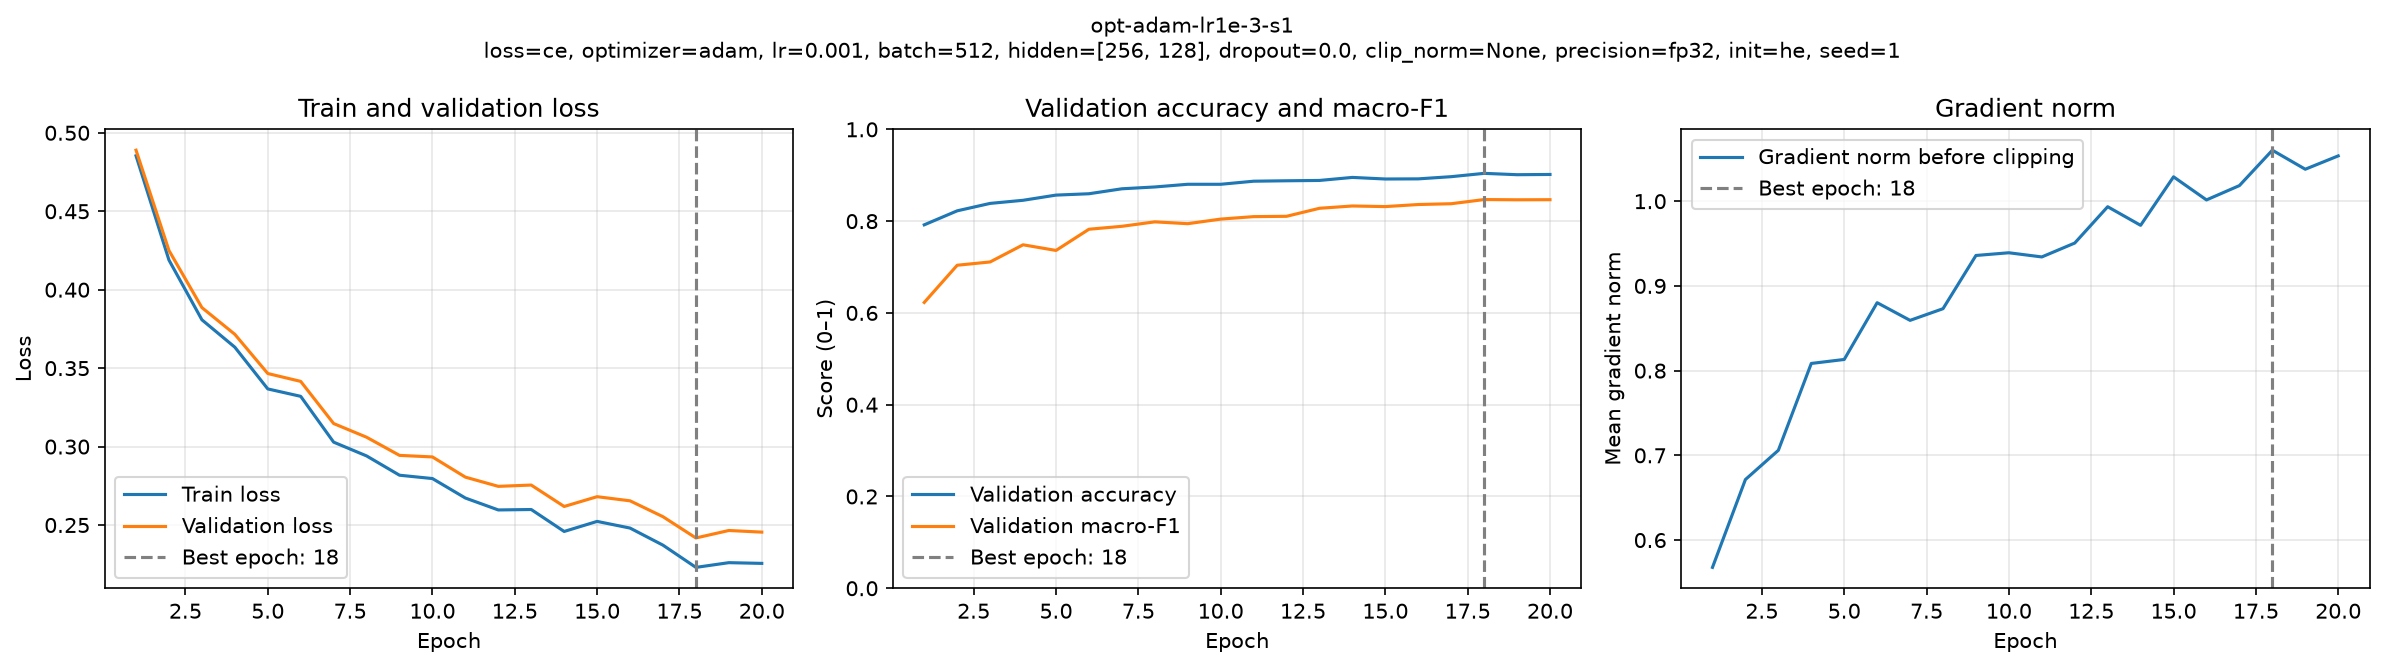

In [12]:
trial = TRIALS[0]
result = run_trial(baseline_cfg, trial, part3_data, OUT_DIR)
part3_results.append(result)
# Cùng split và khởi tạo seed 1 phải có cùng loss trước bước cập nhật đầu tiên.
assert abs(result["summary"]["step0_loss"] - baseline_result["summary"]["step0_loss"]) < 1e-6
display(Image(filename=str(figures_dir / (trial["exp_id"] + ".png"))))


In [13]:
display(Markdown(compare_text(
    part3_results[-1], baseline_result, noise_f1, noise_acc, n_train, 'adam',
)))


**Đối chiếu sau khi chạy:** `opt-adam-lr1e-3-s1` chọn epoch **18** với val loss **0.241746**, accuracy **90.41%**, macro-F1 **0.847013**. So với `base-s1`, F1 đổi **-0.009804**, chưa vượt ngưỡng nhiễu **0.025507**; accuracy đổi **-0.382 điểm phần trăm**, vượt ngưỡng **0.294 điểm phần trăm**.

Dự đoán giảm loss nhanh trong ba epoch đầu chưa khớp khi so với baseline: tại epoch 3, val loss là **0.3886** so với **0.3799**. Adam điều chỉnh mức cập nhật riêng theo lịch sử gradient của từng trọng số; cách giải thích này phù hợp với chênh lệch đường cong, nhưng lần chạy này chưa tách riêng ảnh hưởng của optimizer khỏi learning rate.

Ở epoch cuối, train loss **0.2255**, val loss **0.2455**, khoảng cách **+0.0199**; cả hai được đo ở `eval()`. Gradient trung bình theo epoch nằm trong **0.5678–1.0602** (trước clip; thí nghiệm này không clip). Một điểm loss hoặc gradient chưa đủ kết luận về độ ổn định.

Ngưỡng nhiễu chỉ ước lượng từ ba seed baseline; cấu hình mới mới chạy seed 1. Đây là quan sát trên validation, chưa chứng minh cấu hình thắng ổn định khi đổi seed.

### Thí nghiệm `opt-adam-lr3e-3-s1`

**Yếu tố thay đổi:** Adam lr=0.003; khảo sát lr thứ hai cho Adam.

**Dự đoán trước:** Tăng lr của Adam từ 0.001 lên 0.003 có thể giúp giảm loss nhanh hơn ở đầu quá trình, nhưng cũng có thể làm loss và gradient dao động hơn. Tôi so hai lần chạy Adam và chọn lr bằng macro-F1 tại epoch có val loss thấp nhất.

**Cấu hình bổ sung / giới hạn:** Đổi optimizer và lr so với baseline; so với opt-adam-lr1e-3-s1 chỉ đổi lr; momentum không áp dụng cho Adam; betas=(0.9,0.999); eps=1e-8; weight_decay=0.

{
  "exp_id": "opt-adam-lr3e-3-s1",
  "group": "optimizer",
  "description": "Adam lr=0.003; khảo sát lr thứ hai cho Adam",
  "loss": "ce",
  "optimizer": "adam",
  "lr": 0.003,
  "weight_decay": 0.0,
  "momentum": 0.9,
  "batch": 512,
  "epochs": 20,
  "hidden": [
    256,
    128
  ],
  "dropout": 0.0,
  "init": "he",
  "clip_norm": null,
  "precision": "fp32",
  "seed": 1,
  "notes": "Đổi optimizer và lr so với baseline; so với opt-adam-lr1e-3-s1 chỉ đổi lr; momentum không áp dụng cho Adam; betas=(0.9,0.999); eps=1e-8; weight_decay=0",
  "betas": [
    0.9,
    0.999
  ],
  "eps": 1e-08,
  "verbose": true
}


opt-adam-lr3e-3-s1 | epoch 01/20 | val_loss=0.4342 | F1=0.6725 | steps=727 | 2.55s


opt-adam-lr3e-3-s1 | epoch 02/20 | val_loss=0.3788 | F1=0.7462 | steps=727 | 2.39s


opt-adam-lr3e-3-s1 | epoch 03/20 | val_loss=0.3444 | F1=0.7512 | steps=727 | 2.33s


opt-adam-lr3e-3-s1 | epoch 04/20 | val_loss=0.3141 | F1=0.7947 | steps=727 | 2.36s


...

opt-adam-lr3e-3-s1 | epoch 17/20 | val_loss=0.2225 | F1=0.8694 | steps=727 | 2.42s


opt-adam-lr3e-3-s1 | epoch 18/20 | val_loss=0.2161 | F1=0.8669 | steps=727 | 2.47s


opt-adam-lr3e-3-s1 | epoch 19/20 | val_loss=0.2214 | F1=0.8674 | steps=727 | 2.41s


opt-adam-lr3e-3-s1 | epoch 20/20 | val_loss=0.2095 | F1=0.8782 | steps=727 | 2.46s


{
  "step0_loss": 2.2690618094036408,
  "best_val_loss": 0.20953205985396756,
  "best_epoch": 20,
  "final_train_loss": 0.179863494409432,
  "final_val_loss": 0.20953205985396756,
  "val_acc": 0.9162668617284482,
  "val_macro_f1": 0.8782205973968894,
  "time_per_epoch_s": 2.435596149979392,
  "peak_mem_MB": 0.0,
  "diverged": false,
  "divergence_reason": "",
  "total_update_steps": 14540,
  "total_time_s": 48.71192299958784,
  "device": "cpu",
  "torch_version": "2.14.1+cpu",
  "cpu_threads": 1
}


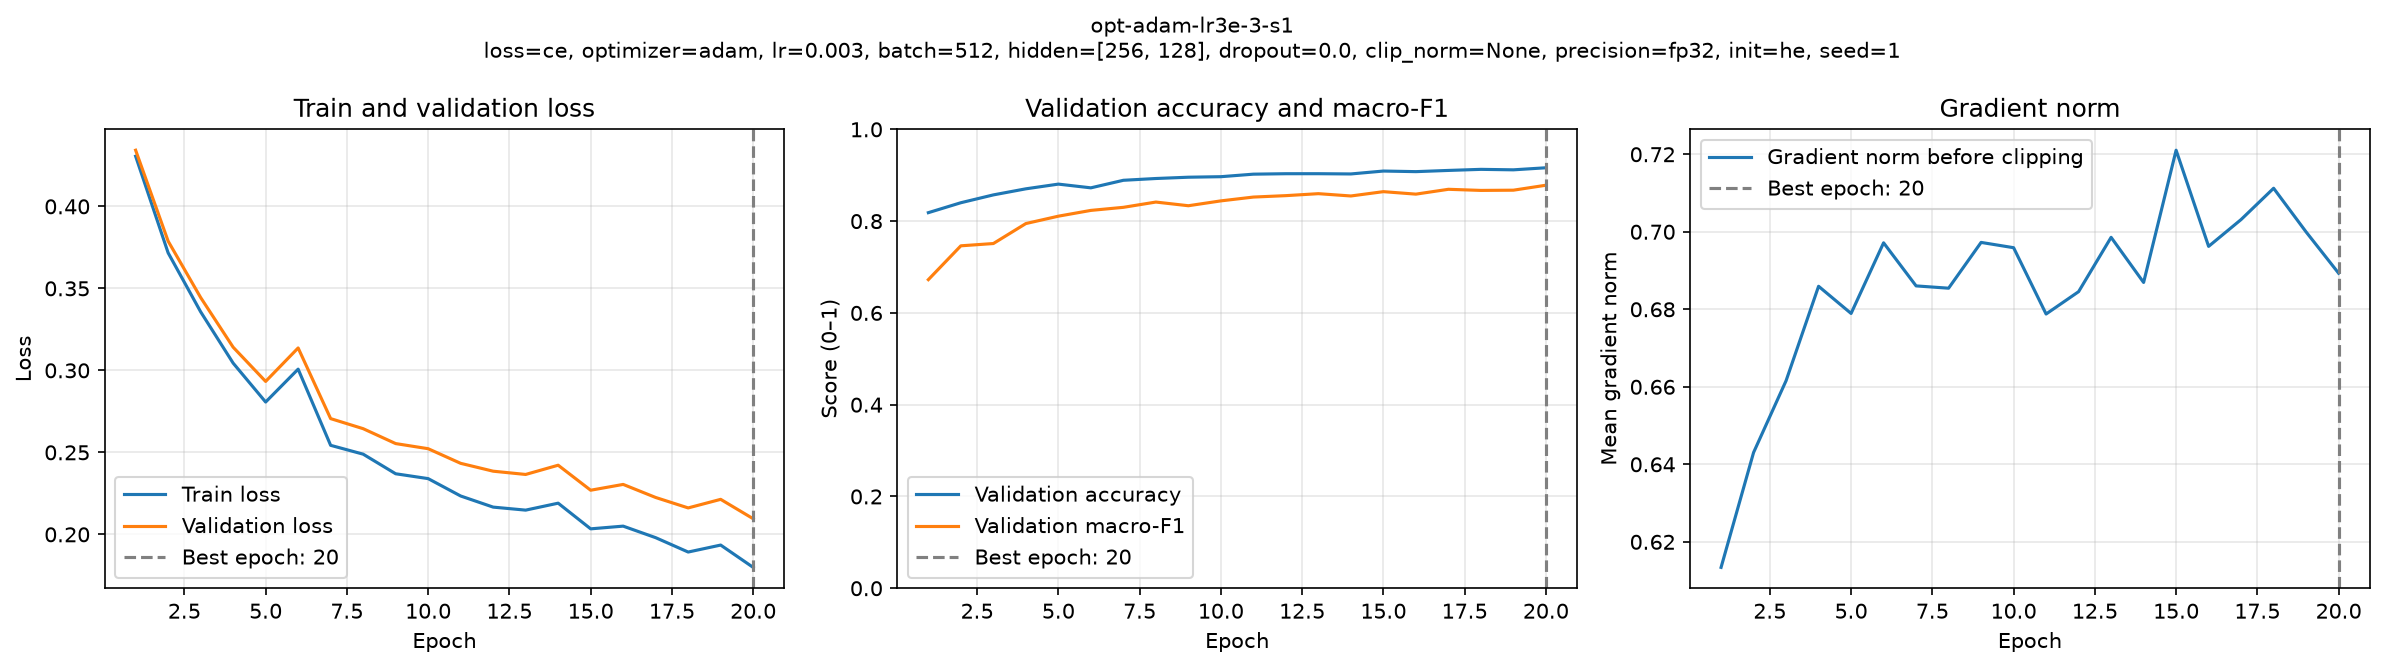

In [14]:
trial = TRIALS[1]
result = run_trial(baseline_cfg, trial, part3_data, OUT_DIR)
part3_results.append(result)
# Cùng split và khởi tạo seed 1 phải có cùng loss trước bước cập nhật đầu tiên.
assert abs(result["summary"]["step0_loss"] - baseline_result["summary"]["step0_loss"]) < 1e-6
display(Image(filename=str(figures_dir / (trial["exp_id"] + ".png"))))


In [15]:
display(Markdown(compare_text(
    part3_results[-1], baseline_result, noise_f1, noise_acc, n_train, 'adam',
)))


**Đối chiếu sau khi chạy:** `opt-adam-lr3e-3-s1` chọn epoch **20** với val loss **0.209532**, accuracy **91.63%**, macro-F1 **0.878221**. So với `base-s1`, F1 đổi **+0.021404**, chưa vượt ngưỡng nhiễu **0.025507**; accuracy đổi **+0.834 điểm phần trăm**, vượt ngưỡng **0.294 điểm phần trăm**.

Dự đoán giảm loss nhanh trong ba epoch đầu khớp khi so với baseline: tại epoch 3, val loss là **0.3444** so với **0.3799**. Adam điều chỉnh mức cập nhật riêng theo lịch sử gradient của từng trọng số; cách giải thích này phù hợp với chênh lệch đường cong, nhưng lần chạy này chưa tách riêng ảnh hưởng của optimizer khỏi learning rate.

Ở epoch cuối, train loss **0.1799**, val loss **0.2095**, khoảng cách **+0.0297**; cả hai được đo ở `eval()`. Gradient trung bình theo epoch nằm trong **0.6134–0.7210** (trước clip; thí nghiệm này không clip). Một điểm loss hoặc gradient chưa đủ kết luận về độ ổn định.

Ngưỡng nhiễu chỉ ước lượng từ ba seed baseline; cấu hình mới mới chạy seed 1. Đây là quan sát trên validation, chưa chứng minh cấu hình thắng ổn định khi đổi seed.

### 3b. Hyper-parameter — batch size

Chỉ đổi số mẫu trong mỗi lô học: **128 / 512 / 2048**. Giữ lô cuối nhỏ hơn batch, không bỏ mẫu. Với 371 847 mẫu train, số bước mỗi epoch lần lượt là **2 906 / 727 / 182**; qua 20 epoch là **58 120 / 14 540 / 3 640**. Khác số bước là một phần của thí nghiệm này; chưa thử giữ cùng số bước hoặc tăng lr theo batch.

### Thí nghiệm `hp-batch128-s1`

**Yếu tố thay đổi:** Chỉ giảm batch từ 512 xuống 128; giữ lr=0.1.

**Dự đoán trước:** Batch 128 tạo gần bốn lần số bước cập nhật so với batch 512 trong cùng 20 epoch; model có thể đạt val tốt hơn nhưng mất nhiều thời gian và dao động hơn ở lr=0.1. Tôi kiểm tra số bước, thời gian, đường loss và macro-F1.

**Cấu hình bổ sung / giới hạn:** Chỉ đổi batch; lr không tăng/giảm theo batch; giữ lô cuối; cùng epoch nhưng khác số bước nên không thể quy mọi khác biệt cho kích thước batch.

{
  "exp_id": "hp-batch128-s1",
  "group": "hparam",
  "description": "Chỉ giảm batch từ 512 xuống 128; giữ lr=0.1",
  "loss": "ce",
  "optimizer": "sgd_momentum",
  "lr": 0.1,
  "weight_decay": 0.0,
  "momentum": 0.9,
  "batch": 128,
  "epochs": 20,
  "hidden": [
    256,
    128
  ],
  "dropout": 0.0,
  "init": "he",
  "clip_norm": null,
  "precision": "fp32",
  "seed": 1,
  "notes": "Chỉ đổi batch; lr không tăng/giảm theo batch; giữ lô cuối; cùng epoch nhưng khác số bước nên không thể quy mọi khác biệt cho kích thước batch",
  "betas": [
    0.9,
    0.999
  ],
  "eps": 1e-08,
  "verbose": true
}


hp-batch128-s1 | epoch 01/20 | val_loss=0.4272 | F1=0.6604 | steps=2906 | 3.56s


hp-batch128-s1 | epoch 02/20 | val_loss=0.3835 | F1=0.7438 | steps=2906 | 3.43s


hp-batch128-s1 | epoch 03/20 | val_loss=0.3388 | F1=0.7646 | steps=2906 | 3.44s


hp-batch128-s1 | epoch 04/20 | val_loss=0.3266 | F1=0.7803 | steps=2906 | 3.54s


...

hp-batch128-s1 | epoch 17/20 | val_loss=0.2340 | F1=0.8486 | steps=2906 | 3.48s


hp-batch128-s1 | epoch 18/20 | val_loss=0.2364 | F1=0.8473 | steps=2906 | 3.56s


hp-batch128-s1 | epoch 19/20 | val_loss=0.2418 | F1=0.8549 | steps=2906 | 3.47s


hp-batch128-s1 | epoch 20/20 | val_loss=0.2245 | F1=0.8594 | steps=2906 | 3.46s


{
  "step0_loss": 2.2690618094036408,
  "best_val_loss": 0.22280704416795472,
  "best_epoch": 15,
  "final_train_loss": 0.19657372990935915,
  "final_val_loss": 0.22452606078395104,
  "val_acc": 0.9101568382780061,
  "val_macro_f1": 0.8525371678466772,
  "time_per_epoch_s": 3.483922260010149,
  "peak_mem_MB": 0.0,
  "diverged": false,
  "divergence_reason": "",
  "total_update_steps": 58120,
  "total_time_s": 69.67844520020299,
  "device": "cpu",
  "torch_version": "2.14.1+cpu",
  "cpu_threads": 1
}


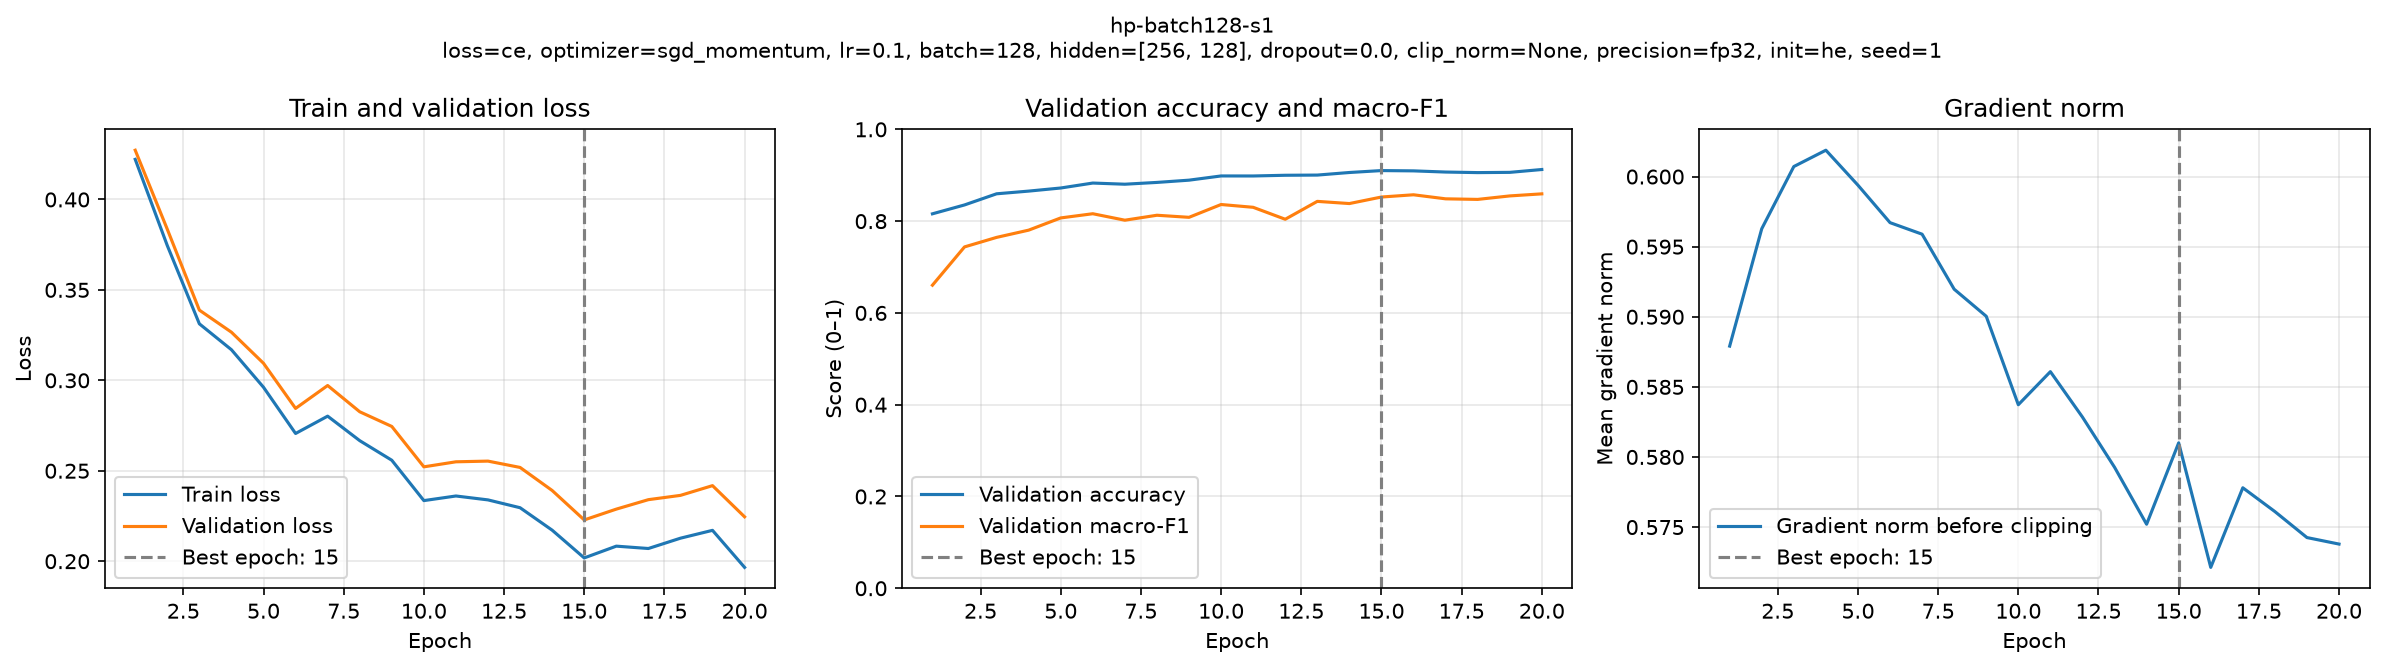

In [16]:
trial = TRIALS[2]
result = run_trial(baseline_cfg, trial, part3_data, OUT_DIR)
part3_results.append(result)
# Cùng split và khởi tạo seed 1 phải có cùng loss trước bước cập nhật đầu tiên.
assert abs(result["summary"]["step0_loss"] - baseline_result["summary"]["step0_loss"]) < 1e-6
display(Image(filename=str(figures_dir / (trial["exp_id"] + ".png"))))


In [17]:
display(Markdown(compare_text(
    part3_results[-1], baseline_result, noise_f1, noise_acc, n_train, 'small_batch',
)))


**Đối chiếu sau khi chạy:** `hp-batch128-s1` chọn epoch **15** với val loss **0.222807**, accuracy **91.02%**, macro-F1 **0.852537**. So với `base-s1`, F1 đổi **-0.004280**, chưa vượt ngưỡng nhiễu **0.025507**; accuracy đổi **+0.223 điểm phần trăm**, chưa vượt ngưỡng **0.294 điểm phần trăm**.

Dự đoán về hướng thay đổi F1 khác kết quả. Số bước cập nhật đo được là **58,120**, baseline có **14,540** bước (tính từ số mẫu, batch và số epoch hoàn tất). Tổng thời gian epoch đo được **69.7s** so với baseline đã lưu **40.8s**. Batch nhỏ cập nhật nhiều lần hơn, batch lớn cập nhật ít lần hơn; vì vậy so cùng epoch chưa tách được ảnh hưởng của batch khỏi số bước. Thời gian baseline là số đo cũ, không có log số luồng CPU nên chỉ tham khảo, chưa đủ kết luận chắc chắn về tốc độ.

Ở epoch cuối, train loss **0.1966**, val loss **0.2245**, khoảng cách **+0.0280**; cả hai được đo ở `eval()`. Gradient trung bình theo epoch nằm trong **0.5721–0.6019** (trước clip; thí nghiệm này không clip). Một điểm loss hoặc gradient chưa đủ kết luận về độ ổn định.

Ngưỡng nhiễu chỉ ước lượng từ ba seed baseline; cấu hình mới mới chạy seed 1. Đây là quan sát trên validation, chưa chứng minh cấu hình thắng ổn định khi đổi seed.

### Thí nghiệm `hp-batch2048-s1`

**Yếu tố thay đổi:** Chỉ tăng batch từ 512 lên 2048; giữ lr=0.1.

**Dự đoán trước:** Batch 2048 chỉ có khoảng một phần tư số bước cập nhật của baseline, nên với cùng lr=0.1 model có thể học chậm hơn tính theo epoch và đạt macro-F1 thấp hơn. Thời gian có thể giảm; tôi chỉ kết luận sau khi đo thời gian và số bước.

**Cấu hình bổ sung / giới hạn:** Chỉ đổi batch; lr không thay đổi; giữ lô cuối; chưa thử tăng lr theo batch hoặc giữ cùng tổng số bước cập nhật.

{
  "exp_id": "hp-batch2048-s1",
  "group": "hparam",
  "description": "Chỉ tăng batch từ 512 lên 2048; giữ lr=0.1",
  "loss": "ce",
  "optimizer": "sgd_momentum",
  "lr": 0.1,
  "weight_decay": 0.0,
  "momentum": 0.9,
  "batch": 2048,
  "epochs": 20,
  "hidden": [
    256,
    128
  ],
  "dropout": 0.0,
  "init": "he",
  "clip_norm": null,
  "precision": "fp32",
  "seed": 1,
  "notes": "Chỉ đổi batch; lr không thay đổi; giữ lô cuối; chưa thử tăng lr theo batch hoặc giữ cùng tổng số bước cập nhật",
  "betas": [
    0.9,
    0.999
  ],
  "eps": 1e-08,
  "verbose": true
}


hp-batch2048-s1 | epoch 01/20 | val_loss=0.5392 | F1=0.5603 | steps=182 | 2.12s


hp-batch2048-s1 | epoch 02/20 | val_loss=0.4929 | F1=0.6409 | steps=182 | 1.88s


hp-batch2048-s1 | epoch 03/20 | val_loss=0.4358 | F1=0.6579 | steps=182 | 1.89s


hp-batch2048-s1 | epoch 04/20 | val_loss=0.4588 | F1=0.6853 | steps=182 | 1.88s


...

hp-batch2048-s1 | epoch 17/20 | val_loss=0.2980 | F1=0.7990 | steps=182 | 1.91s


hp-batch2048-s1 | epoch 18/20 | val_loss=0.2970 | F1=0.8061 | steps=182 | 1.87s


hp-batch2048-s1 | epoch 19/20 | val_loss=0.3060 | F1=0.7842 | steps=182 | 1.92s


hp-batch2048-s1 | epoch 20/20 | val_loss=0.2858 | F1=0.8142 | steps=182 | 1.88s


{
  "step0_loss": 2.2690618094036408,
  "best_val_loss": 0.28575914172465966,
  "best_epoch": 20,
  "final_train_loss": 0.27092581633404916,
  "final_val_loss": 0.28575914172465966,
  "val_acc": 0.8831673156773735,
  "val_macro_f1": 0.8142330299022132,
  "time_per_epoch_s": 1.9213430199946742,
  "peak_mem_MB": 0.0,
  "diverged": false,
  "divergence_reason": "",
  "total_update_steps": 3640,
  "total_time_s": 38.426860399893485,
  "device": "cpu",
  "torch_version": "2.14.1+cpu",
  "cpu_threads": 1
}


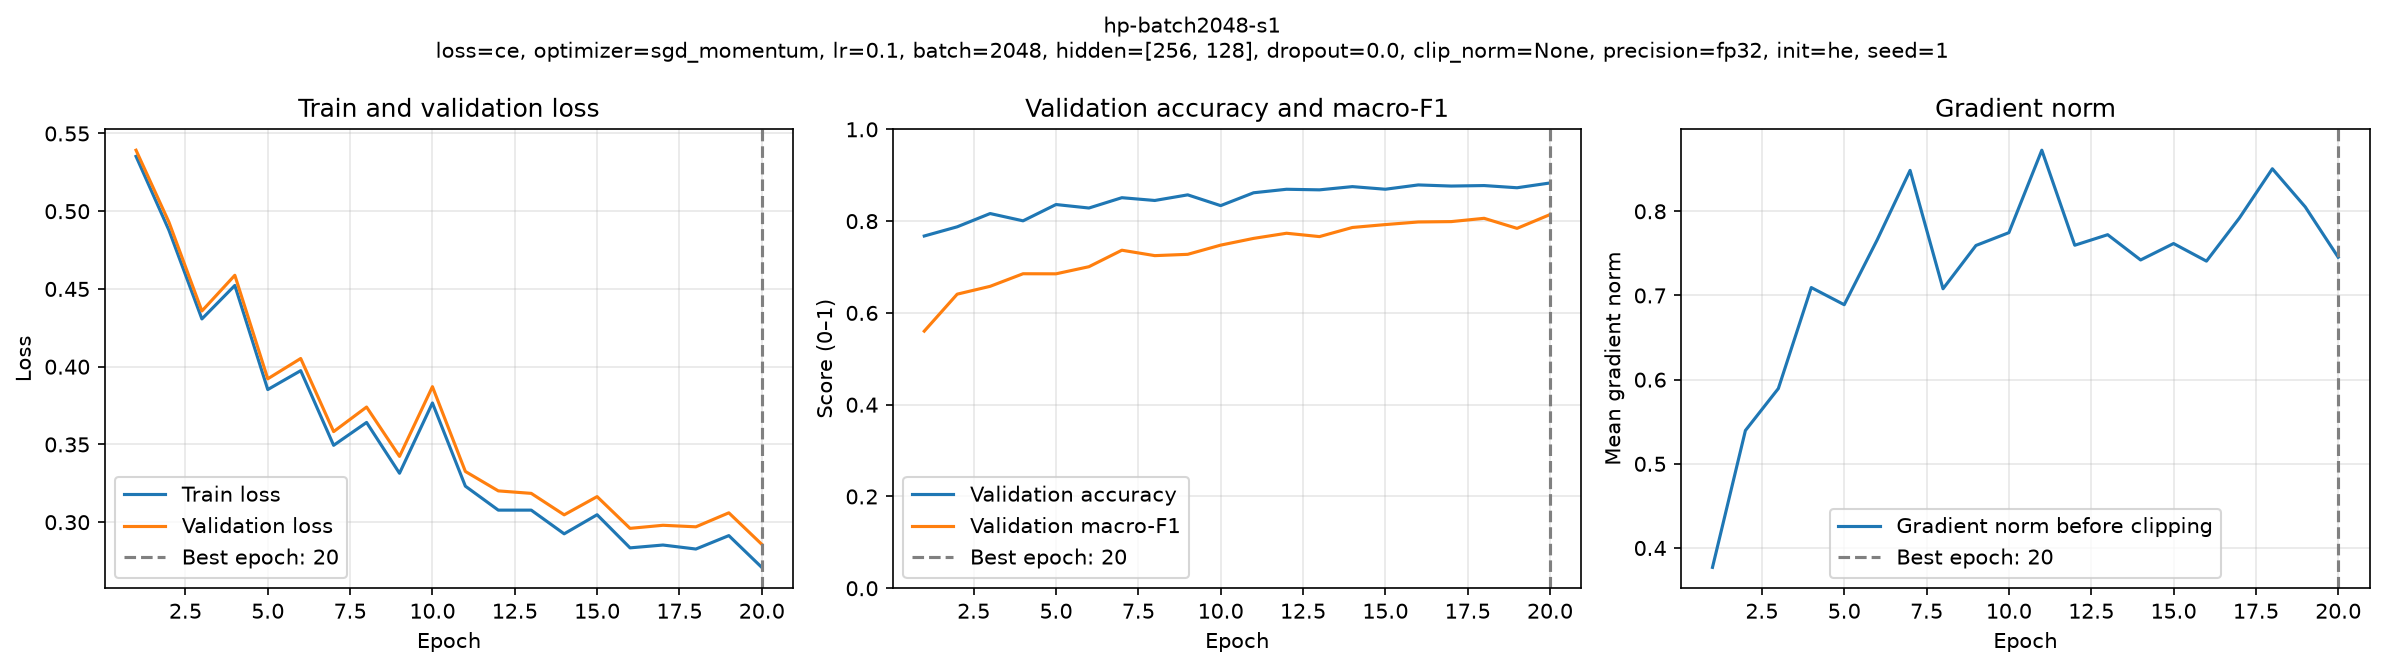

In [18]:
trial = TRIALS[3]
result = run_trial(baseline_cfg, trial, part3_data, OUT_DIR)
part3_results.append(result)
# Cùng split và khởi tạo seed 1 phải có cùng loss trước bước cập nhật đầu tiên.
assert abs(result["summary"]["step0_loss"] - baseline_result["summary"]["step0_loss"]) < 1e-6
display(Image(filename=str(figures_dir / (trial["exp_id"] + ".png"))))


In [19]:
display(Markdown(compare_text(
    part3_results[-1], baseline_result, noise_f1, noise_acc, n_train, 'large_batch',
)))


**Đối chiếu sau khi chạy:** `hp-batch2048-s1` chọn epoch **20** với val loss **0.285759**, accuracy **88.32%**, macro-F1 **0.814233**. So với `base-s1`, F1 đổi **-0.042584**, vượt ngưỡng nhiễu **0.025507**; accuracy đổi **-2.476 điểm phần trăm**, vượt ngưỡng **0.294 điểm phần trăm**.

Dự đoán về hướng thay đổi F1 khớp. Số bước cập nhật đo được là **3,640**, baseline có **14,540** bước (tính từ số mẫu, batch và số epoch hoàn tất). Tổng thời gian epoch đo được **38.4s** so với baseline đã lưu **40.8s**. Batch nhỏ cập nhật nhiều lần hơn, batch lớn cập nhật ít lần hơn; vì vậy so cùng epoch chưa tách được ảnh hưởng của batch khỏi số bước. Thời gian baseline là số đo cũ, không có log số luồng CPU nên chỉ tham khảo, chưa đủ kết luận chắc chắn về tốc độ.

Ở epoch cuối, train loss **0.2709**, val loss **0.2858**, khoảng cách **+0.0148**; cả hai được đo ở `eval()`. Gradient trung bình theo epoch nằm trong **0.3770–0.8726** (trước clip; thí nghiệm này không clip). Một điểm loss hoặc gradient chưa đủ kết luận về độ ổn định.

Ngưỡng nhiễu chỉ ước lượng từ ba seed baseline; cấu hình mới mới chạy seed 1. Đây là quan sát trên validation, chưa chứng minh cấu hình thắng ổn định khi đổi seed.

### 3c. So trực tiếp các đường cong trong từng nhóm

Ảnh learning rate chứa ba cấu hình SGD + momentum của Part 2 và hai Adam mới. Ảnh optimizer chỉ so **lr tốt nhất của mỗi bộ**. Ảnh batch so hai batch mới với baseline. Accuracy và macro-F1 trong bảng đều lấy tại epoch có val loss thấp nhất, không lấy epoch F1 cao nhất.

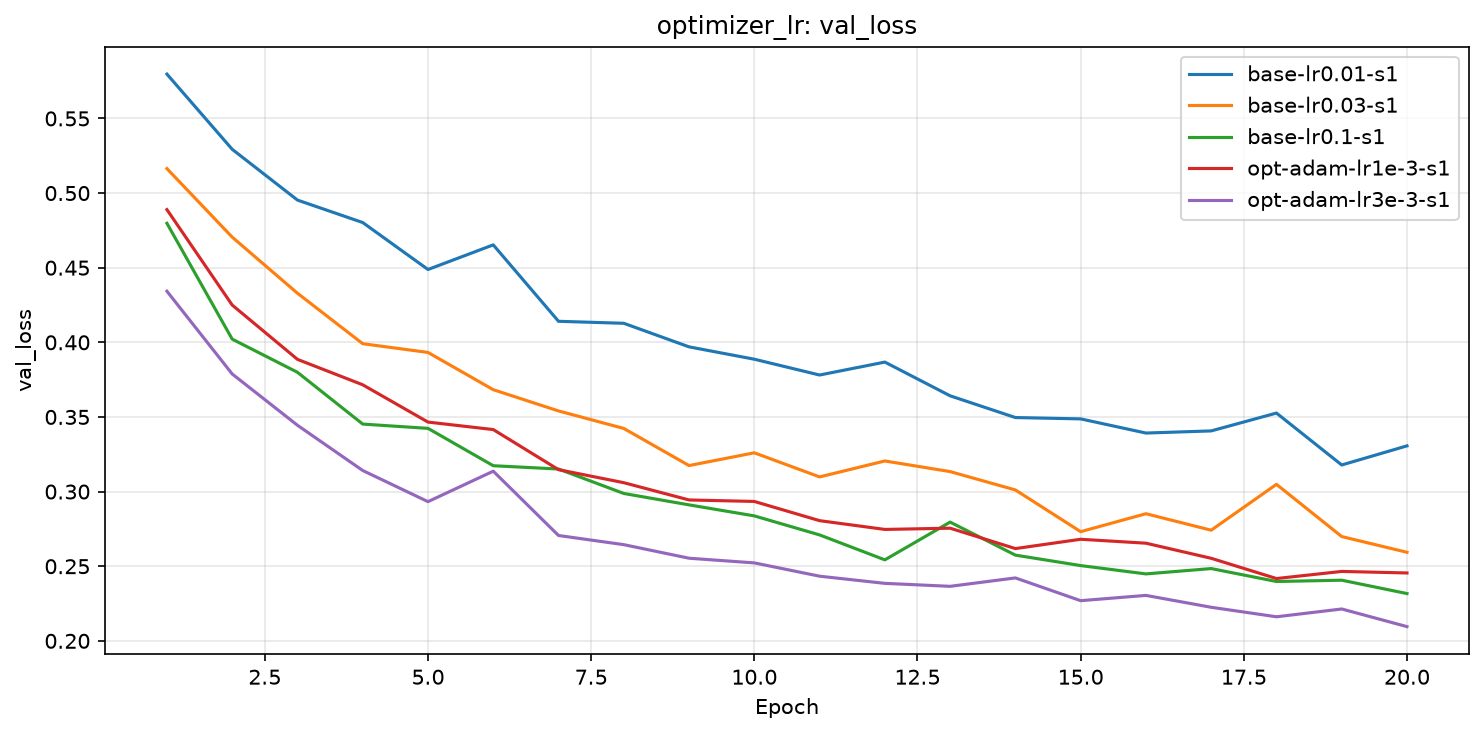

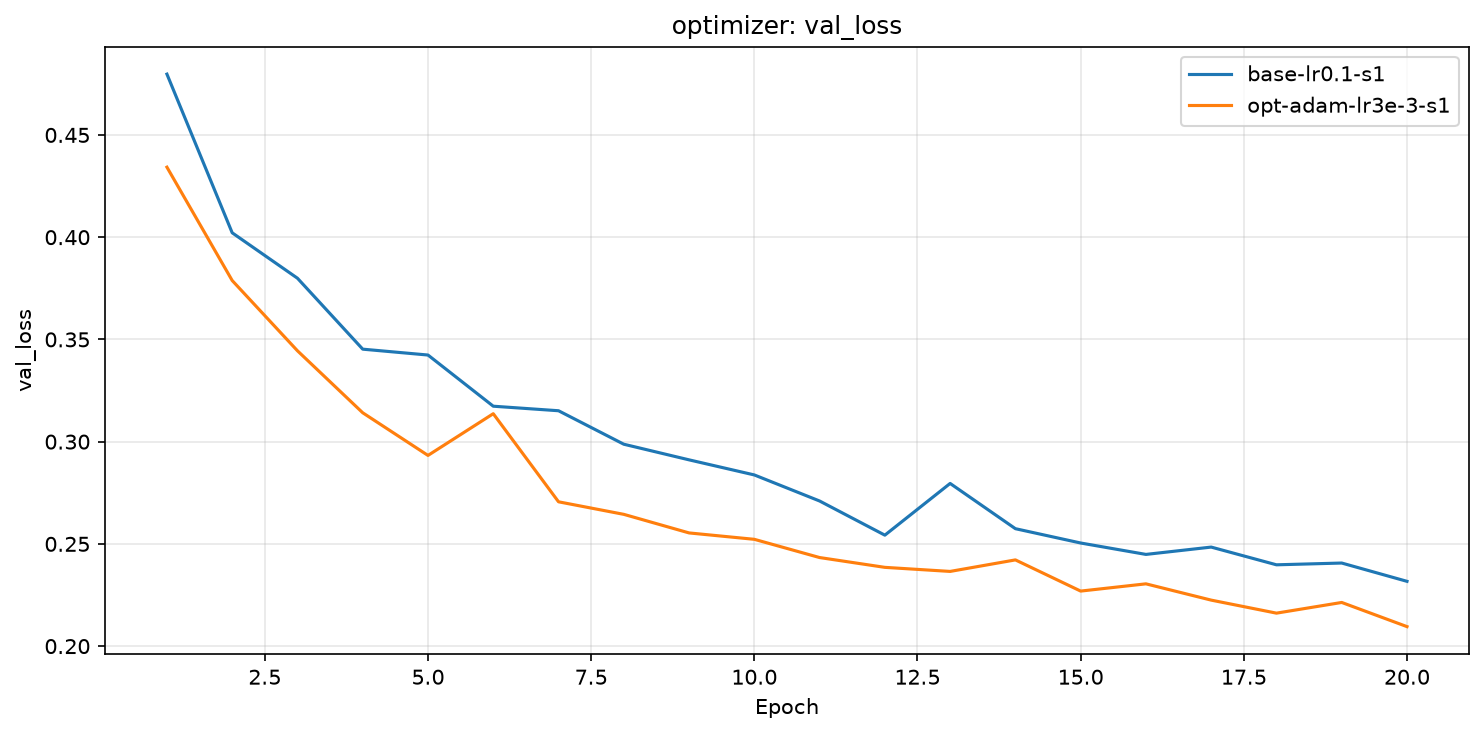

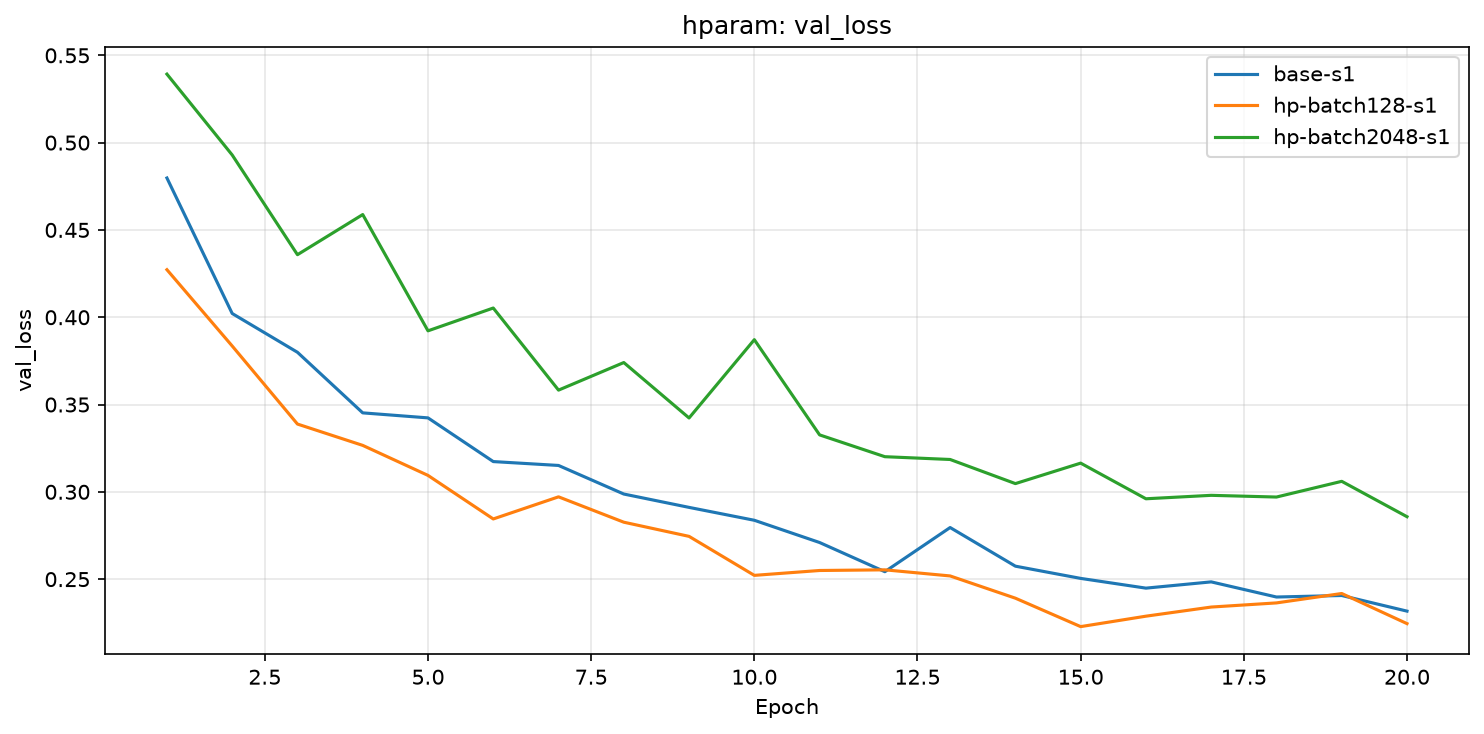

,exp_id,optimizer,lr,batch,best_epoch,best_val_loss,val_acc,val_macro_f1,update_steps,time_per_epoch_s,total_time_s,diverged
0,base-lr0.01-s1,sgd_momentum,0.010,512,19,0.317831,0.871195,0.765155,14540,2.105612,42.112235,False
1,base-lr0.03-s1,sgd_momentum,0.030,512,20,0.259328,0.896140,0.828942,14540,2.194400,43.887994,False
2,base-lr0.1-s1,sgd_momentum,0.100,512,20,0.231681,0.907930,0.856817,14540,2.081385,41.627698,False
3,opt-adam-lr1e-3-s1,adam,0.001,512,18,0.241746,0.904111,0.847013,14540,2.381793,47.635867,False
4,opt-adam-lr3e-3-s1,adam,0.003,512,20,0.209532,0.916267,0.878221,14540,2.435596,48.711923,False
5,hp-batch128-s1,sgd_momentum,0.100,128,15,0.222807,0.910157,0.852537,58120,3.483922,69.678445,False
6,hp-batch2048-s1,sgd_momentum,0.100,2048,20,0.285759,0.883167,0.814233,3640,1.921343,38.426860,False


**Đối chiếu hai lr của Adam:** dự đoán lr=0.003 giảm loss nhanh hơn lr=0.001 khớp tại epoch 3: 0.3444 so với 0.3886. Độ dao động của thay đổi val loss giữa các epoch (độ lệch chuẩn) là 0.0178 so với 0.0161; số này cũng bị ảnh hưởng bởi tốc độ giảm loss, chưa tách được dao động quanh xu hướng. Lr Adam được chọn: **0.003**.

Ở lr tốt nhất đã thử, Adam (opt-adam-lr3e-3-s1) so với SGD+momentum (base-lr0.1-s1) có chênh lệch F1 +0.021404; chưa vượt nhiễu baseline 2σ=0.025507. Mỗi bộ đã thử ít nhất hai lr; chưa kiểm tra nhiều seed của Adam, nên chưa kết luận thắng ổn định. Đây là so sánh trong phạm vi các lr và ngân sách 20 epoch đã thử.

In [20]:
adam_trials = [r for r in part3_results if r["cfg"]["optimizer"] == "adam"]
assert len({r["cfg"]["lr"] for r in adam_trials}) >= 2
best_adam = select_by_val(adam_trials)
optimizer_winners = [best_sgdm, best_adam]
batch_trials = [baseline_result] + [r for r in part3_results if r["cfg"]["group"] == "hparam"]
groups = {
    "optimizer_lr": sgdm_trials + adam_trials,
    "optimizer": optimizer_winners,
    "hparam": batch_trials,
}
for group_name, group_results in groups.items():
    for metric, suffix in (("val_loss", ""), ("val_macro_f1", "_f1")):
        path = figures_dir / f"compare_{group_name}{suffix}.png"
        plot_compare(group_results, metric, str(path), title=f"{group_name}: {metric}")
    display(Image(filename=str(figures_dir / f"compare_{group_name}.png")))
display(comparison_table(sgdm_trials + part3_results, n_train))
comparison_table(sgdm_trials + part3_results, n_train).to_csv(
    Path(OUT_DIR) / "part3_comparison.csv", index=False,
)
f1_difference = best_adam["summary"]["val_macro_f1"] - best_sgdm["summary"]["val_macro_f1"]
adam_low, adam_high = sorted(adam_trials, key=lambda r: r["cfg"]["lr"])
high_faster = adam_high["history"]["val_loss"][2] < adam_low["history"]["val_loss"][2]
low_jitter = float(np.std(np.diff(adam_low["history"]["val_loss"])))
high_jitter = float(np.std(np.diff(adam_high["history"]["val_loss"])))
display(Markdown(
    f"**Đối chiếu hai lr của Adam:** dự đoán lr=0.003 giảm loss nhanh hơn lr=0.001 "
    f"{'khớp' if high_faster else 'khác kết quả'} tại epoch 3: "
    f"{adam_high['history']['val_loss'][2]:.4f} so với {adam_low['history']['val_loss'][2]:.4f}. "
    f"Độ dao động của thay đổi val loss giữa các epoch (độ lệch chuẩn) là "
    f"{high_jitter:.4f} so với {low_jitter:.4f}; số này cũng bị ảnh hưởng bởi tốc độ giảm loss, "
    f"chưa tách được dao động quanh xu hướng. Lr Adam được chọn: **{best_adam['cfg']['lr']}**."
))
optimizer_note = (
    f"Ở lr tốt nhất đã thử, Adam ({best_adam['cfg']['exp_id']}) so với SGD+momentum "
    f"({best_sgdm['cfg']['exp_id']}) có chênh lệch F1 {f1_difference:+.6f}; "
    f"{'vượt' if abs(f1_difference) > noise_f1 else 'chưa vượt'} nhiễu baseline 2σ={noise_f1:.6f}. "
    "Mỗi bộ đã thử ít nhất hai lr; chưa kiểm tra nhiều seed của Adam, nên chưa kết luận thắng ổn định. "
    "Đây là so sánh trong phạm vi các lr và ngân sách 20 epoch đã thử."
)
display(Markdown(optimizer_note))


### 3d. Chốt cấu hình cuối bằng validation — trước Part 4

Áp dụng quy tắc đã đặt ở đầu Part 3. Cấu hình được chọn là một cấu hình đã chạy; không tự ghép optimizer tốt nhất với batch tốt nhất khi chưa đo tổ hợp đó. Seed 2 và 3 chỉ dùng để ước lượng nhiễu baseline, không đưa vào danh sách để chọn seed tốt nhất.

In [21]:
candidates = [baseline_result] + sgdm_trials + part3_results
result_final = select_by_val(candidates)
cfg_final = dict(result_final["cfg"])
final_epoch = result_final["summary"]["best_epoch"]
final_difference = result_final["summary"]["val_macro_f1"] - baseline_result["summary"]["val_macro_f1"]
final_note = (
    f"Chọn **{cfg_final['exp_id']}**, optimizer={cfg_final['optimizer']}, lr={cfg_final['lr']}, "
    f"batch={cfg_final['batch']}, seed={cfg_final['seed']}, epoch có val loss thấp nhất **{final_epoch}**. "
    f"Val loss={result_final['summary']['best_val_loss']:.6f}, "
    f"accuracy={result_final['summary']['val_acc']:.2%}, "
    f"macro-F1={result_final['summary']['val_macro_f1']:.6f}. "
    f"Chênh lệch F1 so với baseline seed 1 là {final_difference:+.6f}; "
    f"{'vượt' if abs(final_difference) > noise_f1 else 'chưa vượt'} ngưỡng 2σ={noise_f1:.6f}. "
    "Đây là lựa chọn theo val trong các cấu hình đã thử; mức cải thiện chưa được xác nhận bằng nhiều seed. "
    "Part 4 phải dùng trọng số của epoch này, không điều chỉnh cấu hình theo điểm eval."
)
selection = {
    "cfg_final": cfg_final, "best_epoch": final_epoch,
    "val_metrics": result_final["summary"],
    "selection_rule": "Highest val_macro_f1 at the minimum-val-loss epoch; tie: lower loss, lower lr",
    "candidate_exp_ids": list(dict.fromkeys(r["cfg"]["exp_id"] for r in candidates)),
    "baseline_noise_f1_2sigma": noise_f1, "reason": final_note, "eval_used": False,
}
(Path(OUT_DIR) / "part3_selection.json").write_text(
    json.dumps(selection, ensure_ascii=False, indent=2) + "\n", encoding="utf-8",
)
display(Markdown(final_note))
print(json.dumps(cfg_final, ensure_ascii=False, indent=2))
if "best_state" not in result_final:
    print("Log cũ không lưu trọng số. Khi chạy notebook từ đầu, result_final có best_state ở RAM; "
          "nếu chỉ đọc JSON, cần chạy lại đúng cấu hình đã chốt trước Part 4.")


Chọn **opt-adam-lr3e-3-s1**, optimizer=adam, lr=0.003, batch=512, seed=1, epoch có val loss thấp nhất **20**. Val loss=0.209532, accuracy=91.63%, macro-F1=0.878221. Chênh lệch F1 so với baseline seed 1 là +0.021404; chưa vượt ngưỡng 2σ=0.025507. Đây là lựa chọn theo val trong các cấu hình đã thử; mức cải thiện chưa được xác nhận bằng nhiều seed. Part 4 phải dùng trọng số của epoch này, không điều chỉnh cấu hình theo điểm eval.

{
  "exp_id": "opt-adam-lr3e-3-s1",
  "group": "optimizer",
  "description": "Adam lr=0.003; khảo sát lr thứ hai cho Adam",
  "loss": "ce",
  "optimizer": "adam",
  "lr": 0.003,
  "weight_decay": 0.0,
  "momentum": 0.9,
  "betas": [
    0.9,
    0.999
  ],
  "eps": 1e-08,
  "batch": 512,
  "epochs": 20,
  "hidden": [
    256,
    128
  ],
  "dropout": 0.0,
  "init": "he",
  "clip_norm": null,
  "precision": "fp32",
  "seed": 1,
  "notes": "Đổi optimizer và lr so với baseline; so với opt-adam-lr1e-3-s1 chỉ đổi lr; momentum không áp dụng cho Adam; betas=(0.9,0.999); eps=1e-8; weight_decay=0",
  "verbose": true
}


### 3e. Ghi bảng thí nghiệm

Lưu tất cả các lần chạy của Part 2 và Part 3 vào `experiments.xlsx`, gồm cả các lần thử lr. Giữ bốn sheet và cột của mẫu. `eval_acc` và `eval_macro_f1` để trống vì chưa đo eval. Cấu hình cuối được đánh dấu trong `notes`, không nhân đôi một lần chạy thành dòng giả mới.

In [22]:
summary_notes = {
    "baseline": f"Ba seed; F1 2σ={noise_f1:.6f}; accuracy 2σ={noise_acc:.6f}. "
                "Ba lr của Part 2 nằm ở group baseline_lr và được dùng lại để so optimizer.",
    "optimizer": optimizer_note,
    "hparam": "Đã thử batch 128/2048, baseline 512; cùng lr=0.1, seed 1 và 20 epoch. "
              "Số bước lần lượt 58120/3640/14540. Chưa kiểm tra cùng số bước hoặc tăng lr theo batch; "
              "thời gian baseline thiếu log số luồng CPU; cấu hình mới mới có một seed.",
    "final": final_note + " Không chạy lại một cấu hình trùng lặp nên đánh dấu lựa chọn trong notes "
             "của dòng gốc; chưa có group final mới.",
    "other": "baseline_lr: ba lần tìm lr của Part 2 đã ghi đủ dòng/ảnh; dùng lại trong so optimizer.",
}
table_path = export_part3_table(
    OUT_DIR, Path(REPO_ROOT) / "templates" / "experiment_table_template.xlsx",
    result_final, summary_notes,
)
print("Đã ghi:", table_path)
print("Các công thức được giữ; Excel tính lại khi mở file.")
print("Hoàn tất Part 3. Cấu hình đã chốt trước khi dùng tập eval ở Part 4.")


Đã ghi: ..\experiments.xlsx
Các công thức được giữ; Excel tính lại khi mở file.
Hoàn tất Part 3. Cấu hình đã chốt trước khi dùng tập eval ở Part 4.


## Part 4 — Đánh giá cuối trên eval, bảng và nộp bài
**Cách đánh giá:** chọn cấu hình CHỈ bằng val → chạy final model → dự đoán trên **toàn bộ** tập eval → ghi `predictions_eval.csv`
→ `python scripts/evaluate.py --pred ...` tính accuracy và **macro-F1** (chỉ số chính). Chỉ làm bước này cho baseline và cấu hình cuối cùng.

In [ ]:
# Part 3 đã chốt cfg_final, result_final và best_epoch; dùng lại quyết định đó.
# TODO: final_eval(cfg_final, result_final, data, f"{OUT_DIR}/predictions_eval.csv")
# TODO: chạy: python scripts/evaluate.py --pred <OUT_DIR>/predictions_eval.csv --out <OUT_DIR>/eval_result.json (từ REPO_ROOT)
# TODO: đọc eval_result.json: ghi accuracy, macro_f1 vào bảng và báo cáo; làm tương tự cho baseline (predictions riêng, không nộp nếu không cần)

In [ ]:
# TODO: phân tích lỗi trên eval: bảng precision/recall/F1 theo lớp (từ eval_result.json) và ma trận nhầm lẫn;
#       lớp nào khó nhất? vì sao (số mẫu ít? nhầm với lớp nào?)  -> viết nhận xét ở ô markdown bên dưới

**Phân tích lỗi (tự viết):** ...

In [ ]:
# Part 3 đã tạo experiments.xlsx và điền Seeds/Summary.
# Part 4 chỉ bổ sung điểm eval cho baseline/cấu hình cuối sau khi chấm bằng evaluate.py.